In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings, os, math, json
warnings.filterwarnings('ignore')

In [ ]:
!pip3 install torch torchvision torchaudio

In [ ]:
class Config:
    DATA_PATH = "merged_data1.csv"
    ENCODER_LENGTH = 10   # lookback window (weeks)
    DECODER_LENGTH = 4      # forecast horizon (weeks)
    HIDDEN_SIZE = 32
    NUM_HEADS = 4
    DROPOUT = 0.3  # increased from 0.2 to reduce overfitting
    NUM_LSTM_LAYERS = 2
    BATCH_SIZE = 32
    EPOCHS = 60  # reduced; early stopping handles the rest
    LR = 1e-3
    SEED = 42
    OUTPUT_DIR = "tft_output"
    QUANTILES = [0.1, 0.5, 0.9]       # P10, P50 (median), P90
    ACCURACY_TOLERANCE = 1.0           # within ±1 larva = "correct"

    # Feature definitions
    TIME_VARYING_KNOWN = [
        'Temperature_Max', 'Temperature_Min',
        'Relative_Humidity_Morning', 'Relative_Humidity_Afternoon',
        'Rainfall', 'No_of_Rainy_Days', 'Sunshine_Hrs',
        'Wind_Velocity', 'Evap'
    ]
    TIME_VARYING_UNKNOWN = ['larva_count']
    STATIC_CATS = ['sowing_type']
    TIME_FEATURES = ['month2', 'week', 'Metro_Week_No']
    TARGET = 'larva_count'
    GROUP_COL = 'sowing_type'
    TIME_IDX = 'time_idx'

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)

In [ ]:
def load_and_preprocess(cfg):
    df = pd.read_csv(cfg.DATA_PATH)
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
    df = df.sort_values(['sowing_type', 'Date']).reset_index(drop=True)

    # Rebuild time_idx per group (continuous integers)
    df['time_idx'] = df.groupby('sowing_type').cumcount()

    # Encode categorical
    le = LabelEncoder()
    df['sowing_type_enc'] = le.fit_transform(df['sowing_type'])

    # Scale continuous features
    cont_cols = cfg.TIME_VARYING_KNOWN + cfg.TIME_VARYING_UNKNOWN + cfg.TIME_FEATURES
    scalers = {}
    for c in cont_cols:
        sc = StandardScaler()
        if c == cfg.TARGET:  # log1p only for larva_count
            df[c + '_scaled'] = sc.fit_transform(np.log1p(df[[c]]))
        else:
            df[c + '_scaled'] = sc.fit_transform(df[[c]])
        scalers[c] = sc

    print(f"Dataset: {len(df)} rows, groups: {df['sowing_type'].unique()}")
    print(f"Target stats: mean={df[cfg.TARGET].mean():.2f}, max={df[cfg.TARGET].max():.1f}")
    print(f"Non-zero targets: {(df[cfg.TARGET] > 0).sum()} / {len(df)}")
    return df, scalers, le

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, df, encoder_len, decoder_len):
        self.samples = []
        cont_known = [c + '_scaled' for c in cfg.TIME_VARYING_KNOWN]
        cont_time = [c + '_scaled' for c in cfg.TIME_FEATURES]
        target_col = cfg.TARGET + '_scaled'

        for grp, gdf in df.groupby('sowing_type'):
            gdf = gdf.sort_values('time_idx').reset_index(drop=True)
            total = encoder_len + decoder_len
            for i in range(len(gdf) - total + 1):
                window = gdf.iloc[i:i + total]
                enc = window.iloc[:encoder_len]
                dec = window.iloc[encoder_len:]

                # Encoder inputs: known + target history + time features
                enc_known = enc[cont_known].values.astype(np.float32)
                enc_target = enc[[target_col]].values.astype(np.float32)
                enc_time = enc[cont_time].values.astype(np.float32)

                # Decoder inputs: known future + time features (no target)
                dec_known = dec[cont_known].values.astype(np.float32)
                dec_time = dec[cont_time].values.astype(np.float32)

                # Static
                static = np.array([enc['sowing_type_enc'].iloc[0]], dtype=np.int64)

                # Target
                target = dec[[target_col]].values.astype(np.float32)
                target_raw = dec[[cfg.TARGET]].values.astype(np.float32)

                self.samples.append({
                    'enc_known': enc_known,
                    'enc_target': enc_target,
                    'enc_time': enc_time,
                    'dec_known': dec_known,
                    'dec_time': dec_time,
                    'static': static,
                    'target': target,
                    'target_raw': target_raw,
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {k: torch.tensor(v) for k, v in s.items()}

In [ ]:
class GLU(nn.Module):
    """Gated Linear Unit"""
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d, d)
        self.fc2 = nn.Linear(d, d)

    def forward(self, x):
        return torch.sigmoid(self.fc2(x)) * self.fc1(x)


class GRN(nn.Module):
    """Gated Residual Network"""
    def __init__(self, d_in, d_hidden, d_out=None, context_dim=None, dropout=0.1):
        super().__init__()
        d_out = d_out or d_in
        self.fc1 = nn.Linear(d_in, d_hidden)
        self.context_fc = nn.Linear(context_dim, d_hidden, bias=False) if context_dim else None
        self.fc2 = nn.Linear(d_hidden, d_out)
        self.glu = GLU(d_out)
        self.ln = nn.LayerNorm(d_out)
        self.dropout = nn.Dropout(dropout)
        self.skip = nn.Linear(d_in, d_out) if d_in != d_out else None

    def forward(self, x, context=None):
        residual = self.skip(x) if self.skip else x
        h = F.elu(self.fc1(x))
        if self.context_fc is not None and context is not None:
            h = h + self.context_fc(context)
        h = self.dropout(F.elu(self.fc2(h)))
        h = self.glu(h)
        return self.ln(h + residual)


class VSN(nn.Module):
    """Variable Selection Network"""
    def __init__(self, d_input, n_vars, d_hidden, context_dim=None, dropout=0.1):
        super().__init__()
        self.n_vars = n_vars
        self.d_input = d_input
        self.flattened_grn = GRN(n_vars * d_input, d_hidden, n_vars, context_dim, dropout)
        self.var_grns = nn.ModuleList([GRN(d_input, d_hidden, d_hidden, dropout=dropout) for _ in range(n_vars)])

    def forward(self, x, context=None):
        # x: (B, T, n_vars * d_input) or (B, n_vars * d_input)
        has_time = x.dim() == 3
        if has_time:
            B, T, _ = x.shape
            flat = x.reshape(B * T, -1)
            ctx = context.unsqueeze(1).expand(-1, T, -1).reshape(B * T, -1) if context is not None else None
        else:
            flat = x
            ctx = context
        weights = torch.softmax(self.flattened_grn(flat, ctx), dim=-1)  # (B*T, n_vars)

        var_inputs = flat.reshape(-1, self.n_vars, self.d_input)
        processed = []
        for i, grn in enumerate(self.var_grns):
            processed.append(grn(var_inputs[:, i, :]))
        processed = torch.stack(processed, dim=1)  # (B*T, n_vars, d_hidden)

        weights = weights.unsqueeze(-1)  # (B*T, n_vars, 1)
        out = (processed * weights).sum(dim=1)  # (B*T, d_hidden)
        if has_time:
            out = out.reshape(B, T, -1)
        return out


class InterpretableMultiHeadAttention(nn.Module):
    """Interpretable Multi-Head Attention (shared value weights)"""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, self.d_k)  # Shared values
        self.out = nn.Linear(self.d_k, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        B, T, _ = q.shape
        Q = self.W_q(q).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v)  # (B, T, d_k) - shared

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = self.dropout(torch.softmax(scores, dim=-1))

        V_exp = V.unsqueeze(1).expand(-1, self.n_heads, -1, -1)
        context = torch.matmul(attn, V_exp)  # (B, n_heads, T, d_k)
        context = context.mean(dim=1)  # Average over heads
        return self.out(context), attn

In [ ]:
class TemporalFusionTransformer(nn.Module):
    def __init__(self, n_known, n_time, n_static_cats, static_cat_sizes,
                 hidden_size, n_heads, dropout, n_lstm_layers,
                 encoder_len, decoder_len):
        super().__init__()
        self.hidden_size = hidden_size
        self.encoder_len = encoder_len
        self.decoder_len = decoder_len
        d = hidden_size

        # --- Static variable embeddings ---
        self.static_embeddings = nn.ModuleList([
            nn.Embedding(size, d) for size in static_cat_sizes
        ])
        n_static = len(static_cat_sizes)
        self.static_grn = GRN(n_static * d, d, d, dropout=dropout)

        # Context vectors for different parts
        self.static_context_variable = GRN(d, d, d, dropout=dropout)
        self.static_context_enrichment = GRN(d, d, d, dropout=dropout)
        self.static_context_state_h = GRN(d, d, d, dropout=dropout)
        self.static_context_state_c = GRN(d, d, d, dropout=dropout)

        # --- Input projections ---
        # Encoder: known features + target + time features
        enc_input_dim = n_known + 1 + n_time  # +1 for target history
        self.enc_var_proj = nn.ModuleList([nn.Linear(1, d) for _ in range(enc_input_dim)])
        self.enc_vsn = VSN(d, enc_input_dim, d, context_dim=d, dropout=dropout)

        # Decoder: known features + time features (no target)
        dec_input_dim = n_known + n_time
        self.dec_var_proj = nn.ModuleList([nn.Linear(1, d) for _ in range(dec_input_dim)])
        self.dec_vsn = VSN(d, dec_input_dim, d, context_dim=d, dropout=dropout)

        # --- Temporal processing ---
        self.lstm_encoder = nn.LSTM(d, d, n_lstm_layers, batch_first=True, dropout=dropout if n_lstm_layers > 1 else 0)
        self.lstm_decoder = nn.LSTM(d, d, n_lstm_layers, batch_first=True, dropout=dropout if n_lstm_layers > 1 else 0)

        # Post-LSTM gate
        self.post_lstm_glu = GLU(d)
        self.post_lstm_ln = nn.LayerNorm(d)

        # --- Static enrichment ---
        self.enrichment_grn = GRN(d, d, d, context_dim=d, dropout=dropout)

        # --- Temporal self-attention ---
        self.multihead_attn = InterpretableMultiHeadAttention(d, n_heads, dropout)
        self.post_attn_glu = GLU(d)
        self.post_attn_ln = nn.LayerNorm(d)

        # --- Position-wise feedforward ---
        self.pos_ff_grn = GRN(d, d, d, dropout=dropout)
        self.pos_ff_glu = GLU(d)
        self.pos_ff_ln = nn.LayerNorm(d)

        # --- Output (quantile predictions) ---
        self.n_quantiles = 3  # P10, P50, P90
        self.output_fc = nn.Linear(d, self.n_quantiles)

    def forward(self, enc_known, enc_target, enc_time, dec_known, dec_time, static):
        B = enc_known.shape[0]
        d = self.hidden_size

        # 1. Static processing
        static_embs = []
        for i, emb in enumerate(self.static_embeddings):
            static_embs.append(emb(static[:, i]))
        static_rep = torch.cat(static_embs, dim=-1)
        static_rep = self.static_grn(static_rep)

        cs_var = self.static_context_variable(static_rep)
        cs_enrich = self.static_context_enrichment(static_rep)
        cs_h = self.static_context_state_h(static_rep)
        cs_c = self.static_context_state_c(static_rep)

        # 2. Variable selection - Encoder
        enc_all = torch.cat([enc_known, enc_target, enc_time], dim=-1)  # (B, T_enc, n_enc_vars)
        enc_vars = []
        for i in range(enc_all.shape[-1]):
            enc_vars.append(self.enc_var_proj[i](enc_all[:, :, i:i+1]))
        enc_projected = torch.cat(enc_vars, dim=-1)  # (B, T_enc, n_vars * d)
        enc_selected = self.enc_vsn(enc_projected, cs_var)

        # 3. Variable selection - Decoder
        dec_all = torch.cat([dec_known, dec_time], dim=-1)
        dec_vars = []
        for i in range(dec_all.shape[-1]):
            dec_vars.append(self.dec_var_proj[i](dec_all[:, :, i:i+1]))
        dec_projected = torch.cat(dec_vars, dim=-1)
        dec_selected = self.dec_vsn(dec_projected, cs_var)

        # 4. LSTM (Local Processing)
        n_layers = self.lstm_encoder.num_layers
        h0 = cs_h.unsqueeze(0).expand(n_layers, -1, -1).contiguous()
        c0 = cs_c.unsqueeze(0).expand(n_layers, -1, -1).contiguous()

        enc_lstm_out, (hn, cn) = self.lstm_encoder(enc_selected, (h0, c0))
        dec_lstm_out, _ = self.lstm_decoder(dec_selected, (hn, cn))

        lstm_out = torch.cat([enc_lstm_out, dec_lstm_out], dim=1)
        vsn_out = torch.cat([enc_selected, dec_selected], dim=1)

        # Post-LSTM gating
        gated = self.post_lstm_glu(lstm_out)
        temporal = self.post_lstm_ln(gated + vsn_out)

        # 5. Static enrichment
        T_total = temporal.size(1)
        temporal_flat = temporal.reshape(B * T_total, d)
        cs_enrich_exp = cs_enrich.unsqueeze(1).expand(-1, T_total, -1).reshape(B * T_total, d)
        enriched = self.enrichment_grn(temporal_flat, cs_enrich_exp).reshape(B, T_total, d)

        # 6. Self-attention (decoder can only attend to past + itself)
        T = enriched.size(1)
        mask = torch.triu(torch.ones(T, T, device=enriched.device), diagonal=1) == 0
        mask = mask.unsqueeze(0).unsqueeze(0)  # (1, 1, T, T)

        attn_out, attn_weights = self.multihead_attn(enriched, enriched, enriched, mask)
        attn_out = self.post_attn_glu(attn_out)
        attn_out = self.post_attn_ln(attn_out + enriched)

        # 7. Position-wise feedforward
        ff_out = self.pos_ff_grn(attn_out)
        ff_out = self.pos_ff_glu(ff_out)
        ff_out = self.pos_ff_ln(ff_out + attn_out)

        # 8. Output (decoder part only) - produces quantile predictions
        dec_out = ff_out[:, self.encoder_len:, :]
        predictions = self.output_fc(dec_out)  # (B, decoder_len, n_quantiles)

        return predictions

In [ ]:
def quantile_loss(predictions, targets, quantiles):
    """Pinball / Quantile loss for all quantiles."""
    # predictions: (B, T, n_quantiles), targets: (B, T, 1)
    target_expanded = targets.expand_as(predictions)
    losses = []
    for i, q in enumerate(quantiles):
        errors = target_expanded[:, :, i] - predictions[:, :, i]
        losses.append(torch.max((q - 1) * errors, q * errors))
    return torch.stack(losses, dim=-1).mean()


def train_epoch(model, loader, optimizer, device, quantiles):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        pred = model(batch['enc_known'], batch['enc_target'], batch['enc_time'],
                     batch['dec_known'], batch['dec_time'], batch['static'])
        loss = quantile_loss(pred, batch['target'], quantiles)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * pred.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, device, quantiles):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            pred = model(batch['enc_known'], batch['enc_target'], batch['enc_time'],
                         batch['dec_known'], batch['dec_time'], batch['static'])
            loss = quantile_loss(pred, batch['target'], quantiles)
            total_loss += loss.item() * pred.size(0)
    return total_loss / len(loader.dataset)


def get_predictions(model, loader, device, target_scaler):
    """Returns P10, P50 (median), P90 predictions and targets in original scale."""
    model.eval()
    all_p10, all_p50, all_p90, all_targets = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            pred = model(batch['enc_known'], batch['enc_target'], batch['enc_time'],
                         batch['dec_known'], batch['dec_time'], batch['static'])
            # pred shape: (B, T, 3) for [P10, P50, P90]
            p = pred.cpu().numpy()
            t = batch['target'].cpu().numpy()

            # Inverse transform each quantile
            p10 = np.expm1(target_scaler.inverse_transform(p[:, :, 0].reshape(-1, 1))).flatten()
            p50 = np.expm1(target_scaler.inverse_transform(p[:, :, 1].reshape(-1, 1))).flatten()
            p90 = np.expm1(target_scaler.inverse_transform(p[:, :, 2].reshape(-1, 1))).flatten()
            tgt = np.expm1(target_scaler.inverse_transform(t.reshape(-1, 1))).flatten()

            all_p10.extend(p10)
            all_p50.extend(p50)
            all_p90.extend(p90)
            all_targets.extend(tgt)

    return (np.array(all_p10), np.array(all_p50), np.array(all_p90),
            np.array(all_targets))


def compute_accuracy_metrics(p10, p50, p90, targets, tolerance):
    """Compute accuracy and quantile coverage metrics."""
    n = len(targets)

    # 1. Tolerance-based accuracy: % of P50 predictions within ±tolerance of actual (considering only non-zero targets)
    nonzero_mask = targets > 0
    if nonzero_mask.sum() > 0:
        within_tol = np.abs(p50[nonzero_mask] - targets[nonzero_mask]) <= tolerance
        accuracy_pct = 100.0 * within_tol.sum() / nonzero_mask.sum()
    else:
        accuracy_pct = 0.0

    # 2. Quantile coverage: % of actuals falling within [P10, P90] interval
    in_interval = (targets >= p10) & (targets <= p90)
    coverage_pct = 100.0 * in_interval.sum() / n

    # 3. Directional accuracy: does the model correctly predict increase/decrease?
    if n > 1:
        actual_dir = np.diff(targets) >= 0
        pred_dir = np.diff(p50) >= 0
        directional_acc = 100.0 * (actual_dir == pred_dir).sum() / len(actual_dir)
    else:
        directional_acc = 0.0

    # 4. Zero-class accuracy: when actual=0, does model predict near-0?
    zero_mask = targets == 0
    if zero_mask.sum() > 0:
        zero_acc = 100.0 * (np.abs(p50[zero_mask]) <= tolerance).sum() / zero_mask.sum()
    else:
        zero_acc = 0.0

    # 5. Non-zero accuracy: when actual>0, is prediction within tolerance?
    nonzero_mask = targets > 0
    if nonzero_mask.sum() > 0:
        nonzero_acc = 100.0 * (np.abs(p50[nonzero_mask] - targets[nonzero_mask]) <= tolerance).sum() / nonzero_mask.sum()
    else:
        nonzero_acc = 0.0

    # 6. Mean prediction interval width
    interval_width = np.mean(p90 - p10)

    return {
        'accuracy_pct': accuracy_pct,
        'coverage_pct': coverage_pct,
        'directional_acc': directional_acc,
        'zero_class_acc': zero_acc,
        'nonzero_class_acc': nonzero_acc,
        'mean_interval_width': interval_width,
    }

In [ ]:
def plot_results(train_losses, val_losses, p10, p50, p90, targets, output_dir):
    """Comprehensive visualization suite for TFT results."""

    os.makedirs(output_dir, exist_ok=True)
    ACTUAL_COLOR   = '#2ECC71'
    PRED_COLOR     = '#E74C3C'
    BAND_COLOR     = '#F39C12'
    ERROR_COLOR    = '#9B59B6'
    ZERO_COLOR     = '#95A5A6'

    # ── 1. TRAINING & VALIDATION LOSS CURVE ─────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    epochs = np.arange(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, label='Train Loss', color='#2980B9', linewidth=2)
    ax.plot(epochs, val_losses,   label='Val Loss',   color='#E74C3C', linewidth=2)

    ax.fill_between(epochs, train_losses, val_losses,
                    where=np.array(val_losses) > np.array(train_losses),
                    alpha=0.1, color='red', label='Overfit region')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Quantile Loss', fontsize=12)
    ax.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/1_loss_curve.png', dpi=150);
    plt.show()
    plt.close()

    # ── 2. ACTUAL vs PREDICTED (TIME SERIES) — nonzero only ─────────────
    nonzero_mask = targets > 0
    nz_targets = targets[nonzero_mask]
    nz_p50     = p50[nonzero_mask]
    nz_p10     = p10[nonzero_mask]
    nz_p90     = p90[nonzero_mask]
    n_show     = min(150, len(nz_targets))
    x          = np.arange(n_show)

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.fill_between(x, nz_p10[:n_show], nz_p90[:n_show],
                    alpha=0.25, color=BAND_COLOR, label='P10–P90 band')
    ax.plot(x, nz_targets[:n_show], color=ACTUAL_COLOR,
            linewidth=2, label='Actual', alpha=0.9)
    ax.plot(x, nz_p50[:n_show], color=PRED_COLOR, linewidth=1.8,
            linestyle='--', label='Predicted (P50)', alpha=0.85)
    ax.set_xlabel('Sample Index (nonzero actuals only)', fontsize=12)
    ax.set_ylabel('Larva Count', fontsize=12)
    ax.set_title('Actual vs Predicted Larva Count\n(Nonzero actuals, with P10–P90 uncertainty band)',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/2_actual_vs_predicted.png', dpi=150);
    plt.show()
    plt.close()

    # ── 3. SCATTER PLOT: Predicted vs Actual ────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(nz_targets, nz_p50, alpha=0.45, s=25, c=ERROR_COLOR,
               label='P50 predictions', edgecolors='none')
    mn, mx = 0, max(nz_targets.max(), nz_p50.max()) + 1
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect fit')
    ax.plot([mn, mx], [mn + cfg.ACCURACY_TOLERANCE, mx + cfg.ACCURACY_TOLERANCE],
            color='gray', linewidth=1, linestyle=':', label=f'±{cfg.ACCURACY_TOLERANCE} tolerance')
    ax.plot([mn, mx], [mn - cfg.ACCURACY_TOLERANCE, mx - cfg.ACCURACY_TOLERANCE],
            color='gray', linewidth=1, linestyle=':')
    ax.set_xlabel('Actual Larva Count', fontsize=12)
    ax.set_ylabel('Predicted Larva Count (P50)', fontsize=12)
    ax.set_title('Scatter: Predicted vs Actual\n(Nonzero actuals)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/3_scatter.png', dpi=150);
    plt.show()
    plt.close()

    # ── 4. RESIDUAL / ERROR PLOT ─────────────────────────────────────────
    errors = nz_p50 - nz_targets      # positive = overpredict, negative = underpredict
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 4a. Error over time
    axes[0].bar(np.arange(len(errors)), errors,
                color=[PRED_COLOR if e > 0 else ACTUAL_COLOR for e in errors],
                alpha=0.7, width=1.0)
    axes[0].axhline(0, color='black', linewidth=1.2)
    axes[0].axhline(cfg.ACCURACY_TOLERANCE, color='gray', linestyle='--', linewidth=1,
                    label=f'+{cfg.ACCURACY_TOLERANCE} tolerance')
    axes[0].axhline(-cfg.ACCURACY_TOLERANCE, color='gray', linestyle='--', linewidth=1,
                    label=f'-{cfg.ACCURACY_TOLERANCE} tolerance')
    axes[0].set_xlabel('Sample Index', fontsize=11)
    axes[0].set_ylabel('Prediction Error (P50 - Actual)', fontsize=11)
    axes[0].set_title('Residuals Over Time\nRed = overpredict, Green = underpredict',
                      fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

    # 4b. Error distribution histogram
    axes[1].hist(errors, bins=30, color=ERROR_COLOR, alpha=0.75, edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=1.5, label='Zero error')
    axes[1].axvline(np.mean(errors), color=PRED_COLOR, linewidth=1.8,
                    linestyle='--', label=f'Mean error ({np.mean(errors):.2f})')
    axes[1].axvline(np.median(errors), color=ACTUAL_COLOR, linewidth=1.8,
                    linestyle='--', label=f'Median error ({np.median(errors):.2f})')
    axes[1].set_xlabel('Prediction Error', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Error Distribution\n(Nonzero actuals)', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{output_dir}/4_residuals.png', dpi=150);
    plt.show()
    plt.close()

    # ── 5. QUANTILE COVERAGE (P10–P90) ───────────────────────────────────
    below  = (targets < p10).mean() * 100
    within = ((targets >= p10) & (targets <= p90)).mean() * 100
    above  = (targets > p90).mean() * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # 5a. Coverage bar chart
    bars = axes[0].bar(['Below P10', 'Within P10–P90', 'Above P90'],
                       [below, within, above],
                       color=['#E74C3C', '#2ECC71', '#3498DB'],
                       edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, [below, within, above]):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 1.5, f'{val:.1f}%',
                     ha='center', fontweight='bold', fontsize=13)
    axes[0].axhline(80, color='gray', linestyle='--', linewidth=1.2,
                    label='80% ideal coverage')
    axes[0].set_ylabel('% of Samples', fontsize=11)
    axes[0].set_title('Quantile Coverage (P10–P90)\nAll samples', fontsize=12, fontweight='bold')
    axes[0].set_ylim(0, 115); axes[0].legend(); axes[0].grid(True, alpha=0.2, axis='y')

    # 5b. Prediction interval width distribution
    widths = p90 - p10
    axes[1].hist(widths, bins=25, color=BAND_COLOR, alpha=0.8, edgecolor='white')
    axes[1].axvline(np.mean(widths), color='red', linewidth=1.8, linestyle='--',
                    label=f'Mean width ({np.mean(widths):.2f})')
    axes[1].set_xlabel('P90 - P10 Interval Width', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Prediction Interval Width\n(Narrower = more confident)',
                      fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{output_dir}/5_quantile_coverage.png', dpi=150);
    plt.show()
    plt.close()

    # ── 6. ACCURACY BREAKDOWN — Zero vs Nonzero ──────────────────────────
    zero_mask    = targets == 0
    nz_acc = 100.0 * (np.abs(nz_p50 - nz_targets) <= cfg.ACCURACY_TOLERANCE).mean()
    z_acc  = 100.0 * (np.abs(p50[zero_mask]) <= cfg.ACCURACY_TOLERANCE).mean() \
             if zero_mask.sum() > 0 else 0.0
    overall_acc = 100.0 * (np.abs(p50 - targets) <= cfg.ACCURACY_TOLERANCE).mean()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # 6a. Accuracy bars
    categories = ['Overall', 'Nonzero actuals\n(main metric)', 'Zero actuals']
    values     = [overall_acc, nz_acc, z_acc]
    colors     = ['#3498DB', '#2ECC71', ZERO_COLOR]
    bars = axes[0].bar(categories, values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 1.2, f'{val:.1f}%',
                     ha='center', fontweight='bold', fontsize=13)
    axes[0].set_ylabel('Accuracy (%)', fontsize=11)
    axes[0].set_ylim(0, 115)
    axes[0].set_title(f'Accuracy within ±{cfg.ACCURACY_TOLERANCE} larva\nBreakdown by actual value class',
                      fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.2, axis='y')

    # 6b. Zero vs Nonzero sample count pie
    axes[1].pie([zero_mask.sum(), nonzero_mask.sum()],
                labels=[f'Zero actuals\n({zero_mask.sum()})',
                        f'Nonzero actuals\n({nonzero_mask.sum()})'],
                colors=[ZERO_COLOR, ACTUAL_COLOR],
                autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 12})
    axes[1].set_title('Test Set Composition\n(Zero vs Nonzero actual larva counts)',
                      fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/6_accuracy_breakdown.png', dpi=150);
    plt.show()
    plt.close()

    # ── 7. HIGH-ERROR SAMPLES SPOTLIGHT ──────────────────────────────────
    abs_errors = np.abs(errors)
    threshold  = np.percentile(abs_errors, 90)   # top 10% worst predictions
    high_err_mask = abs_errors >= threshold

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(np.arange(len(nz_targets)), nz_targets,
            color=ACTUAL_COLOR, linewidth=1.5, label='Actual', alpha=0.8)
    ax.plot(np.arange(len(nz_p50)), nz_p50,
            color=PRED_COLOR, linewidth=1.5, linestyle='--', label='Predicted (P50)', alpha=0.8)
    ax.scatter(np.where(high_err_mask)[0], nz_targets[high_err_mask],
               color='black', zorder=5, s=50, label=f'High error (top 10%, ≥{threshold:.1f})')
    ax.set_xlabel('Sample Index (nonzero actuals)', fontsize=12)
    ax.set_ylabel('Larva Count', fontsize=12)
    ax.set_title('High-Error Samples Spotlight\n(Black dots = worst 10% predictions)',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/7_high_error_samples.png', dpi=150);
    plt.show()
    plt.close()

    print(f"\nAll 7 plots saved to '{output_dir}/':")
    print("  1_loss_curve.png            — Training & val loss with best epoch")
    print("  2_actual_vs_predicted.png   — Time series: actual vs P50 + P10-P90 band")
    print("  3_scatter.png               — Scatter: predicted vs actual with tolerance lines")
    print("  4_residuals.png             — Residual bar chart + error histogram")
    print("  5_quantile_coverage.png     — P10-P90 coverage + interval width distribution")
    print("  6_accuracy_breakdown.png    — Accuracy by class + zero/nonzero composition pie")
    print("  7_high_error_samples.png    — Worst 10% predictions highlighted")

  Temporal Fusion Transformer - Larva Count Prediction
Device: cuda
Dataset: 1086 rows, groups: ['early sowing' 'late sowing']
Target stats: mean=0.73, max=25.0
Non-zero targets: 267 / 1086

Split: Train=760, Val=182, Test=184
Samples: Train=734, Val=156, Test=158

Model parameters: 222,291

  Training Started
Epoch   1/60 | Train Loss: 0.202189 | Val Loss: 0.091448 *
Epoch   5/60 | Train Loss: 0.136076 | Val Loss: 0.077011 *
Epoch  10/60 | Train Loss: 0.112432 | Val Loss: 0.069543 *
Epoch  15/60 | Train Loss: 0.095712 | Val Loss: 0.077695
Epoch  20/60 | Train Loss: 0.083775 | Val Loss: 0.067173
Epoch  25/60 | Train Loss: 0.076091 | Val Loss: 0.061619
Epoch  30/60 | Train Loss: 0.066205 | Val Loss: 0.066809

Early stopping at epoch 31

Loaded best model (val_loss=0.058871)

  Sample Predictions (Actual vs Predicted)
Sample   1 | Actual:     0.00 | P10:     0.00 | P50:     0.00 | P90:     0.13
Sample   2 | Actual:     0.00 | P10:     0.00 | P50:     0.00 | P90:     0.15
Sample   3 | Act

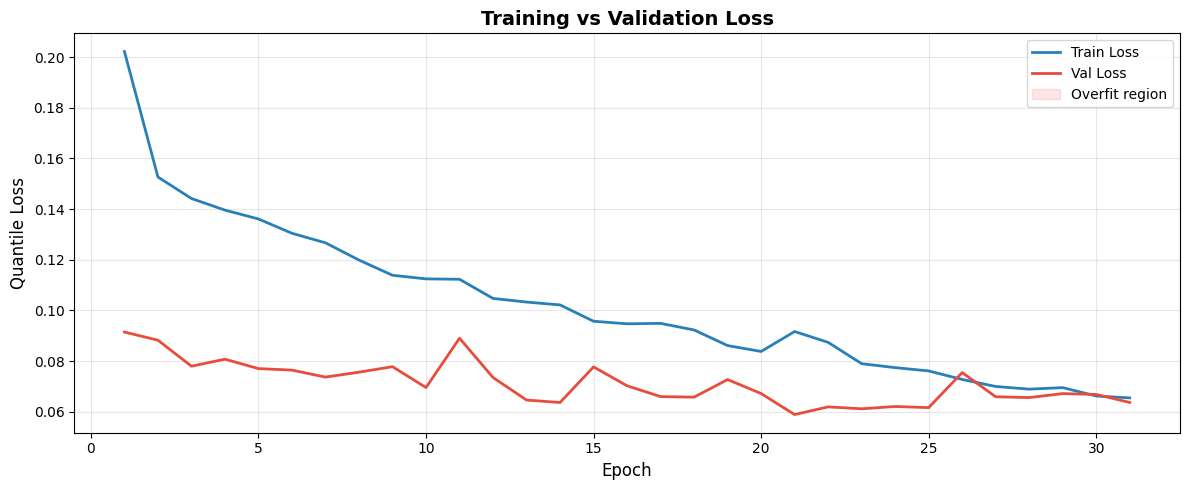

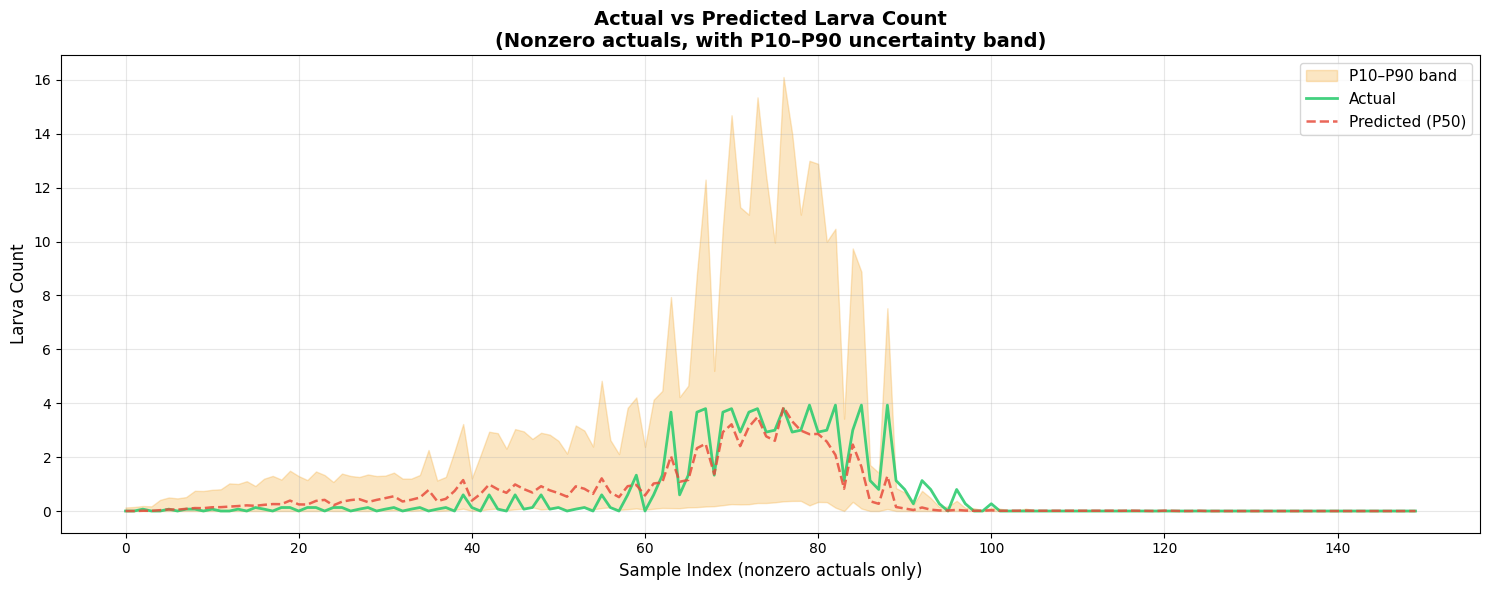

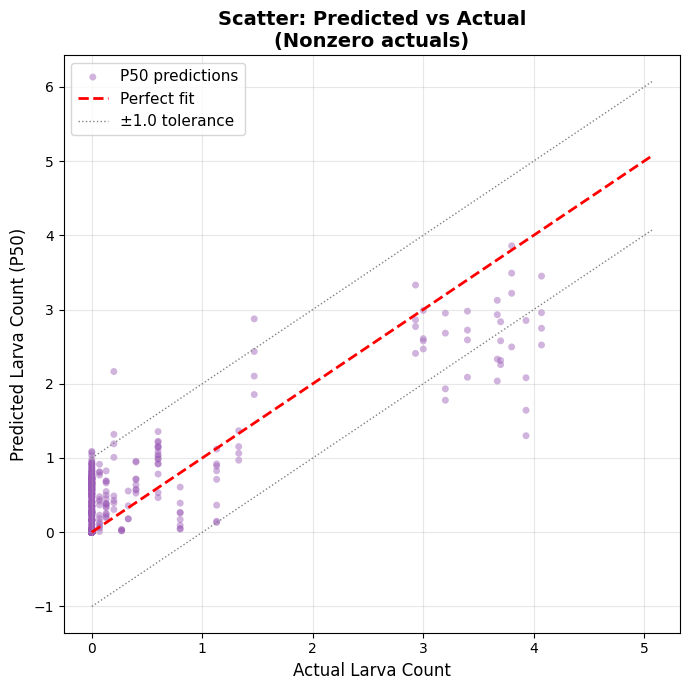

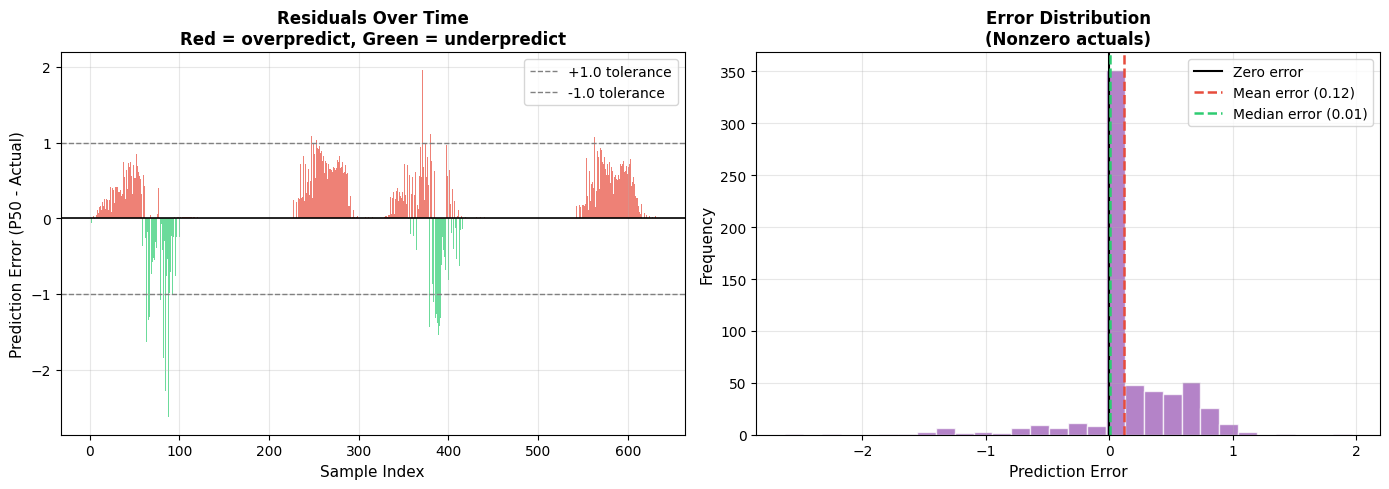

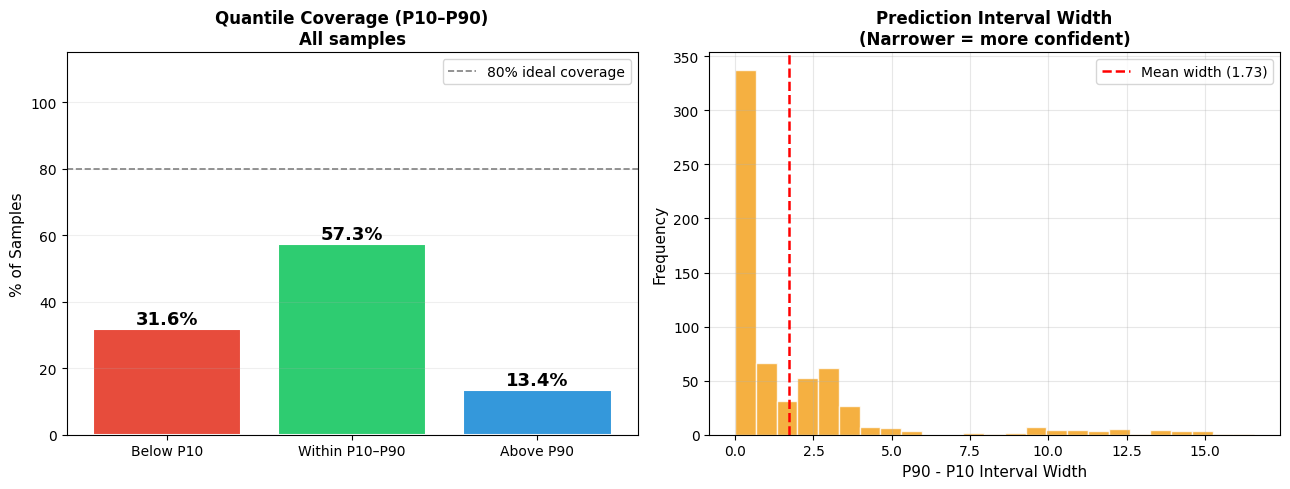

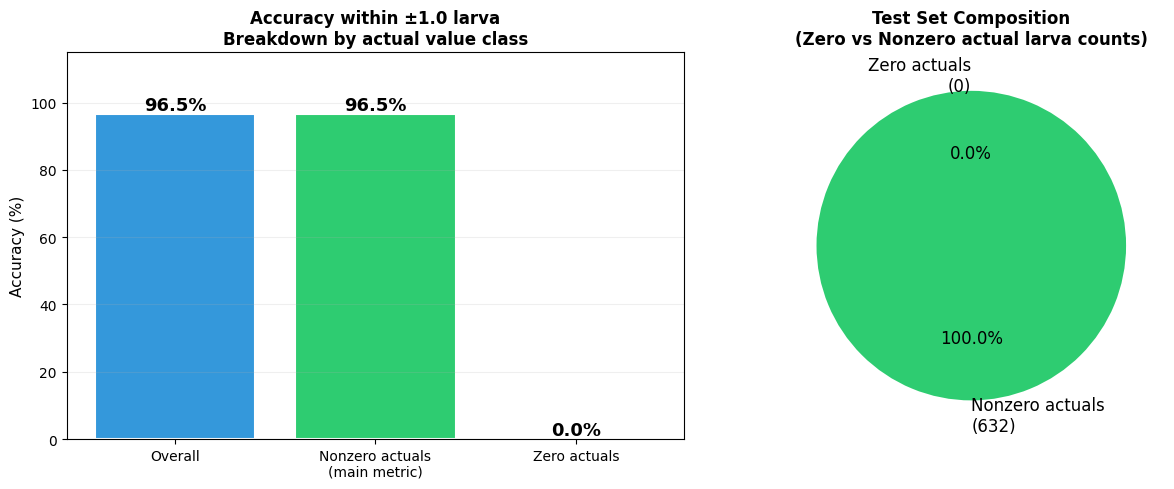

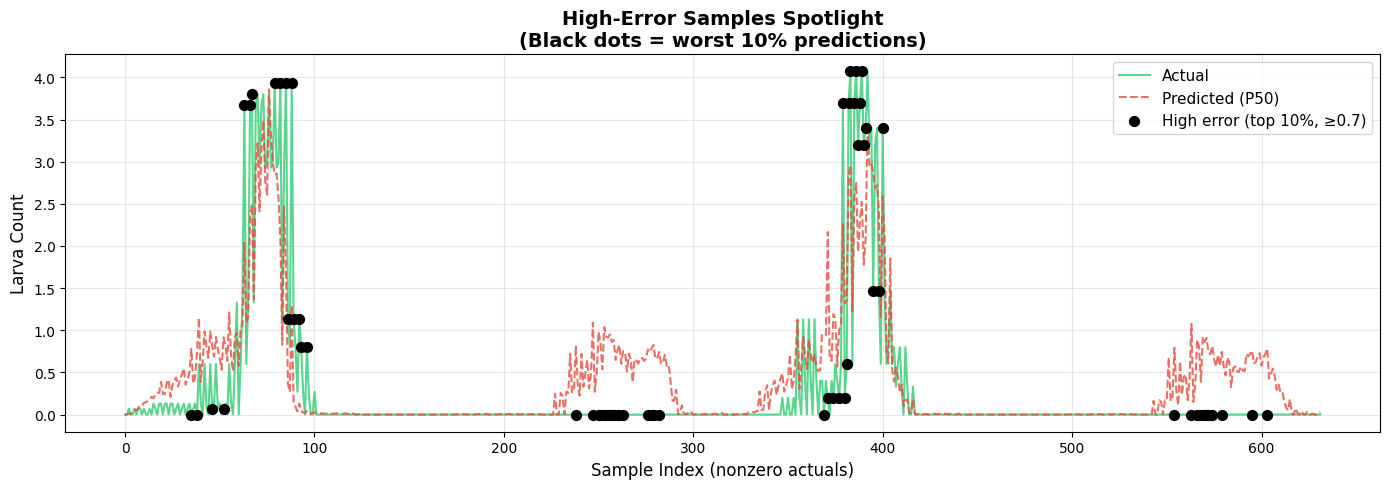


All 7 plots saved to 'tft_output/':
  1_loss_curve.png            — Training & val loss with best epoch
  2_actual_vs_predicted.png   — Time series: actual vs P50 + P10-P90 band
  3_scatter.png               — Scatter: predicted vs actual with tolerance lines
  4_residuals.png             — Residual bar chart + error histogram
  5_quantile_coverage.png     — P10-P90 coverage + interval width distribution
  6_accuracy_breakdown.png    — Accuracy by class + zero/nonzero composition pie
  7_high_error_samples.png    — Worst 10% predictions highlighted

All outputs saved to 'tft_output/'
Files: best_model.pt, metrics.json, loss_curve.png,
       predictions_quantile.png, scatter.png, quantile_coverage.png


In [ ]:
def main():
    print("=" * 60)
    print("  Temporal Fusion Transformer - Larva Count Prediction")
    print("=" * 60)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    # Load data
    cfg = Config() # Re-initialize cfg to ensure latest config is used
    df, scalers, le = load_and_preprocess(cfg)

    # Train/Val/Test split by time
    groups = df.groupby('sowing_type')
    train_frames, val_frames, test_frames = [], [], []
    for name, gdf in groups:
        n = len(gdf)
        train_end = int(n * 0.7)
        val_end = int(n * 0.85)
        train_frames.append(gdf.iloc[:train_end])
        val_frames.append(gdf.iloc[train_end - cfg.ENCODER_LENGTH:val_end])  # overlap for context
        test_frames.append(gdf.iloc[val_end - cfg.ENCODER_LENGTH:])

    train_df = pd.concat(train_frames)
    val_df = pd.concat(val_frames)
    test_df = pd.concat(test_frames)

    print(f"\nSplit: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

    # Create datasets
    train_ds = TimeSeriesDataset(train_df, cfg.ENCODER_LENGTH, cfg.DECODER_LENGTH)
    val_ds = TimeSeriesDataset(val_df, cfg.ENCODER_LENGTH, cfg.DECODER_LENGTH)
    test_ds = TimeSeriesDataset(test_df, cfg.ENCODER_LENGTH, cfg.DECODER_LENGTH)

    print(f"Samples: Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)}")

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)

    # Build model
    n_known = len(cfg.TIME_VARYING_KNOWN)
    n_time = len(cfg.TIME_FEATURES)
    static_cat_sizes = [df['sowing_type_enc'].nunique()]

    model = TemporalFusionTransformer(
        n_known=n_known,
        n_time=n_time,
        n_static_cats=len(static_cat_sizes),
        static_cat_sizes=static_cat_sizes,
        hidden_size=cfg.HIDDEN_SIZE,
        n_heads=cfg.NUM_HEADS,
        dropout=cfg.DROPOUT,
        n_lstm_layers=cfg.NUM_LSTM_LAYERS,
        encoder_len=cfg.ENCODER_LENGTH,
        decoder_len=cfg.DECODER_LENGTH,
    ).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nModel parameters: {total_params:,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LR, weight_decay=1e-4)  # L2 regularisation added
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    # Training loop
    print(f"\n{'='*60}")
    print("  Training Started")
    print(f"{'='*60}")

    train_losses, val_losses = [], []
    best_val = float('inf')
    patience_counter = 0

    quantiles = cfg.QUANTILES

    for epoch in range(1, cfg.EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, optimizer, device, quantiles)
        val_loss = evaluate(model, val_loader, device, quantiles)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), f'{cfg.OUTPUT_DIR}/best_model.pt')
            patience_counter = 0
            marker = ' *'
        else:
            patience_counter += 1
            marker = ''

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{cfg.EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}{marker}")

        if patience_counter >= 10:  # reduced from 20 to stop earlier
            print(f"\nEarly stopping at epoch {epoch}")
            break

    # Load best model
    model.load_state_dict(torch.load(f'{cfg.OUTPUT_DIR}/best_model.pt'))
    print(f"\nLoaded best model (val_loss={best_val:.6f})")

    # Test evaluation
    target_scaler = scalers[cfg.TARGET]
    p10, p50, p90, targets = get_predictions(model, test_loader, device, target_scaler)

    # Clip negative predictions to 0
    p10 = np.clip(p10, 0, None)
    p50 = np.clip(p50, 0, None)
    p90 = np.clip(p90, 0, None)

    # ==============================
    # Show Predictions
    # ==============================
    print(f"\n{'='*60}")
    print("  Sample Predictions (Actual vs Predicted)")
    print(f"{'='*60}")

    num_samples_to_show = min(20, len(targets))

    for i in range(num_samples_to_show):
        print(
            f"Sample {i+1:3d} | "
            f"Actual: {targets[i]:8.2f} | "
            f"P10: {p10[i]:8.2f} | "
            f"P50: {p50[i]:8.2f} | "
            f"P90: {p90[i]:8.2f}"
        )

    # Standard regression metrics (on median P50)
    mae = mean_absolute_error(targets, p50)
    rmse = np.sqrt(mean_squared_error(targets, p50))
    r2 = r2_score(targets, p50) if np.var(targets) > 0 else 0

    # Accuracy & quantile metrics
    acc_metrics = compute_accuracy_metrics(p10, p50, p90, targets, cfg.ACCURACY_TOLERANCE)

    print(f"\n{'='*60}")
    print("  Test Results")
    print(f"{'='*60}")
    print(f"  MAE:              {mae:.4f}")
    print(f"  RMSE:             {rmse:.4f}")
    print(f"  R2:               {r2:.4f}")
    print(f"  ---")
    print(f"  Accuracy (+-{cfg.ACCURACY_TOLERANCE}, nonzero only): {acc_metrics['accuracy_pct']:.1f}%")
    print(f"  P10-P90 Coverage: {acc_metrics['coverage_pct']:.1f}%")
    print(f"  Directional Acc:  {acc_metrics['directional_acc']:.1f}%")
    print(f"  Zero-class Acc:   {acc_metrics['zero_class_acc']:.1f}%")
    print(f"  Nonzero-class Acc:{acc_metrics['nonzero_class_acc']:.1f}%")
    print(f"  Mean Interval:    {acc_metrics['mean_interval_width']:.2f}")
    print(f"{'='*60}")

    # Save metrics
    metrics = {
        'MAE': float(mae), 'RMSE': float(rmse), 'R2': float(r2),
        'accuracy_pct': float(acc_metrics['accuracy_pct']),
        'P10_P90_coverage_pct': float(acc_metrics['coverage_pct']),
        'directional_accuracy_pct': float(acc_metrics['directional_acc']),
        'zero_class_accuracy_pct': float(acc_metrics['zero_class_acc']),
        'nonzero_class_accuracy_pct': float(acc_metrics['nonzero_class_acc']),
        'mean_prediction_interval_width': float(acc_metrics['mean_interval_width']),
        'best_val_loss': float(best_val),
        'epochs_trained': len(train_losses),
        'tolerance': float(cfg.ACCURACY_TOLERANCE),
        'quantiles': cfg.QUANTILES,
    }
    with open(f'{cfg.OUTPUT_DIR}/metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)

    # Plot
    plot_results(train_losses, val_losses, p10, p50, p90, targets, cfg.OUTPUT_DIR)

    print(f"\nAll outputs saved to '{cfg.OUTPUT_DIR}/'")
    print("Files: best_model.pt, metrics.json, loss_curve.png,")
    print("       predictions_quantile.png, scatter.png, quantile_coverage.png")

if __name__ == '__main__':
    main()